# LEAR ensemble: full-run predictions and metrics

Loads the completed backtest over `load-windsolar` features — hour-by-hour ensemble
forecast vs. observed price for every zone, plus the per-zone error summary — and
plots a sample week for DK1.

## 0. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

# Resolve experiments/ relative to the notebook, wherever it is opened from.
CANDIDATES = [Path("experiments"), Path("../experiments"), Path("../../experiments")]
EXPERIMENTS = next((p for p in CANDIDATES if (p / "predictions_load-windsolar.csv").exists()), None)
if EXPERIMENTS is None:
    raise FileNotFoundError(
        "predictions_load-windsolar.csv not found under experiments/. Set EXPERIMENTS manually."
    )
print("experiments dir:", EXPERIMENTS.resolve())

experiments dir: C:\Users\Frede\OneDrive\Skrivebord\Masters Thesis v2\Code\EPF_Masters\experiments


## 1. Load predictions, observations and metrics

In [2]:
predictions = pd.read_csv(EXPERIMENTS / "predictions_load-windsolar.csv", parse_dates=["timestamp_local"])
summary = pd.read_csv(EXPERIMENTS / "summary_load-windsolar.csv")

print(f"predictions: {len(predictions):,} rows, zones: {sorted(predictions['zone'].unique())}")
print(f"span: {predictions['timestamp_local'].min()} -> {predictions['timestamp_local'].max()}")
predictions.head(3)

predictions: 174,720 rows, zones: ['DK1', 'DK2', 'NO1', 'NO2', 'NO3', 'NO4', 'SE1', 'SE2', 'SE3', 'SE4']
span: 2023-10-04 00:00:00 -> 2025-09-30 23:00:00


,timestamp_local,zone,forecast,observed
0,2023-10-04 00:00:00,DK1,15.678297,0.13
1,2023-10-04 01:00:00,DK1,15.735529,0.01
2,2023-10-04 02:00:00,DK1,8.570726,-0.02


## 2. Per-zone metrics

`mae_ensemble` / `rmae_ensemble` are the ensemble's error; the `mae_cw*` / `rmae_cw*`
columns are the individual calibration-window members it's built from.

In [3]:
summary.sort_values("mae_ensemble").reset_index(drop=True)

,zone,days,unobserved_hours,mae_ensemble,rmae_ensemble,mae_cw56,rmae_cw56,mae_cw84,rmae_cw84,mae_cw1092,rmae_cw1092,mae_cw1456,rmae_cw1456
0,NO4,728,2,5.2691,0.46704,5.8648,0.51985,5.6776,0.50325,5.4380,0.48201,5.4422,0.48238
1,NO3,728,2,7.6947,0.45156,8.9008,0.52234,8.6490,0.50757,7.6667,0.44992,7.6806,0.45073
2,SE2,728,2,8.6323,0.41292,9.5909,0.45877,9.2815,0.44397,9.3979,0.44954,9.4131,0.45027
3,SE1,728,2,9.1352,0.44349,10.1137,0.49100,9.8147,0.47648,9.5831,0.46524,9.5913,0.46563
4,NO1,728,2,12.2828,0.53966,13.8751,0.60962,13.5569,0.59564,12.2978,0.54032,12.1406,0.53341
5,NO2,728,2,12.3548,0.53066,13.8397,0.59444,13.2991,0.57122,12.5572,0.53936,12.5176,0.53766
6,SE3,728,2,14.2164,0.47332,15.9688,0.53166,15.5238,0.51685,15.8738,0.52850,15.9737,0.53183
7,DK1,728,2,18.1349,0.47896,20.7457,0.54791,20.2391,0.53453,18.2471,0.48192,18.1921,0.48047
8,SE4,728,2,18.8364,0.48997,21.3106,0.55433,20.8477,0.54229,20.3836,0.53022,20.4850,0.53286
9,DK2,728,2,19.2913,0.48624,22.3403,0.56309,21.5029,0.54198,19.8804,0.50109,19.7207,0.49706


## 3. Sample week: DK1 observed vs. forecast

A full Monday–Sunday week taken from the middle of the run, so the sample avoids both
the unusually calm opening days and the two DST-gap hours flagged as `unobserved_hours`
in the summary above.

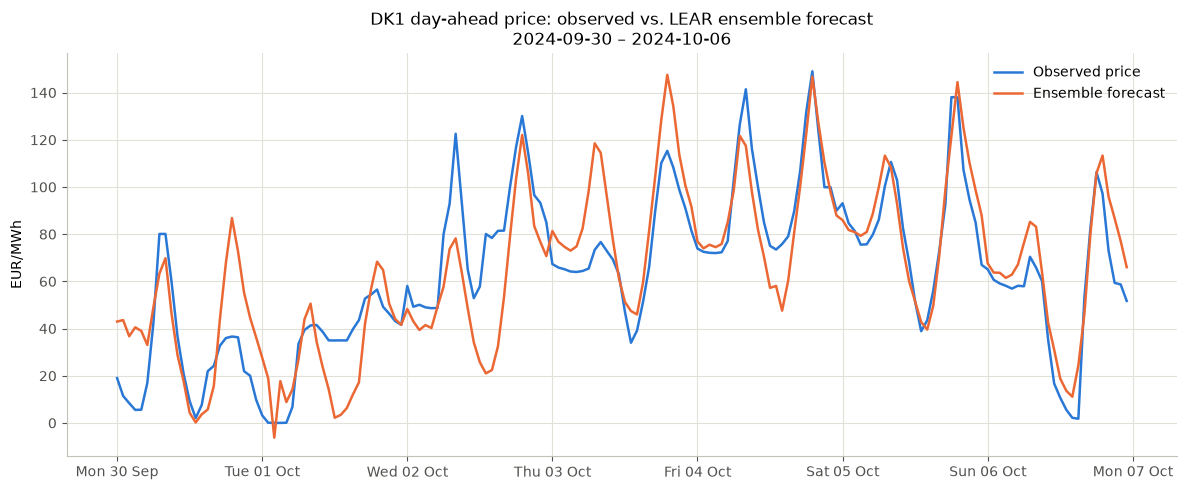

In [9]:
dk1 = predictions[predictions["zone"] == "DK1"].set_index("timestamp_local").sort_index()

mid = dk1.index.min() + (dk1.index.max() - dk1.index.min()) / 2
week_start = (mid - pd.Timedelta(days=mid.dayofweek)).normalize()
week_end = week_start + pd.Timedelta(days=7)
sample = dk1.loc[week_start:week_end - pd.Timedelta(hours=1)]

COLOR_OBSERVED = "#2a78d6"
COLOR_FORECAST = "#eb6834"

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample.index, sample["observed"], color=COLOR_OBSERVED, linewidth=1.8, label="Observed price")
ax.plot(sample.index, sample["forecast"], color=COLOR_FORECAST, linewidth=1.8, label="Ensemble forecast")

ax.set_title(
    f"DK1 day-ahead price: observed vs. LEAR ensemble forecast\n"
    f"{week_start.date()} – {(week_end - pd.Timedelta(days=1)).date()}"
)
ax.set_ylabel("EUR/MWh")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()